In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
# Dark Mode Plots
plt.style.use('dark_background')
import corner
import ast

In [66]:
# Make the corner plot for the MCMC results
system_name = 'J0924'
model_ver = 'sie'
mcmc_samples_path = f'../{system_name}/mcmc/{model_ver}_mcmc.dat'
samples = pd.read_csv(mcmc_samples_path, delim_whitespace=True, header=None, names=['chi2', 'vel_disp', 'x', 'y', 'ellip', 'pa' ])


In [67]:
samples

,chi2,vel_disp,x,y,ellip,pa
0,33.91922,216.0470,-0.197492,-0.830631,0.304143,95.83517
1,34.14829,216.0868,-0.198256,-0.831285,0.304117,95.75667
2,34.94329,216.1445,-0.199742,-0.827999,0.307192,95.75193
3,37.76514,216.4001,-0.203094,-0.828218,0.305244,95.75330
4,38.56761,216.1580,-0.199161,-0.836754,0.305293,95.82909
...,...,...,...,...,...,...
2431,38.91445,216.5075,-0.202006,-0.822767,0.322719,95.63932
2432,37.39219,215.9820,-0.201962,-0.821765,0.330695,95.74896
2433,40.54705,216.3817,-0.211225,-0.826894,0.330486,95.75820
2434,42.39658,216.4185,-0.214486,-0.823544,0.330596,95.61714


In [68]:
masked_samples = samples.drop(columns=['chi2']).to_numpy()

In [69]:
# # Masked Samples with no accept column
# masked_samples = samples[samples['accept'] == 'accept'].copy()
# masked_samples = masked_samples.drop(columns=['accept', 'chi2']).to_numpy()
# masked_samples

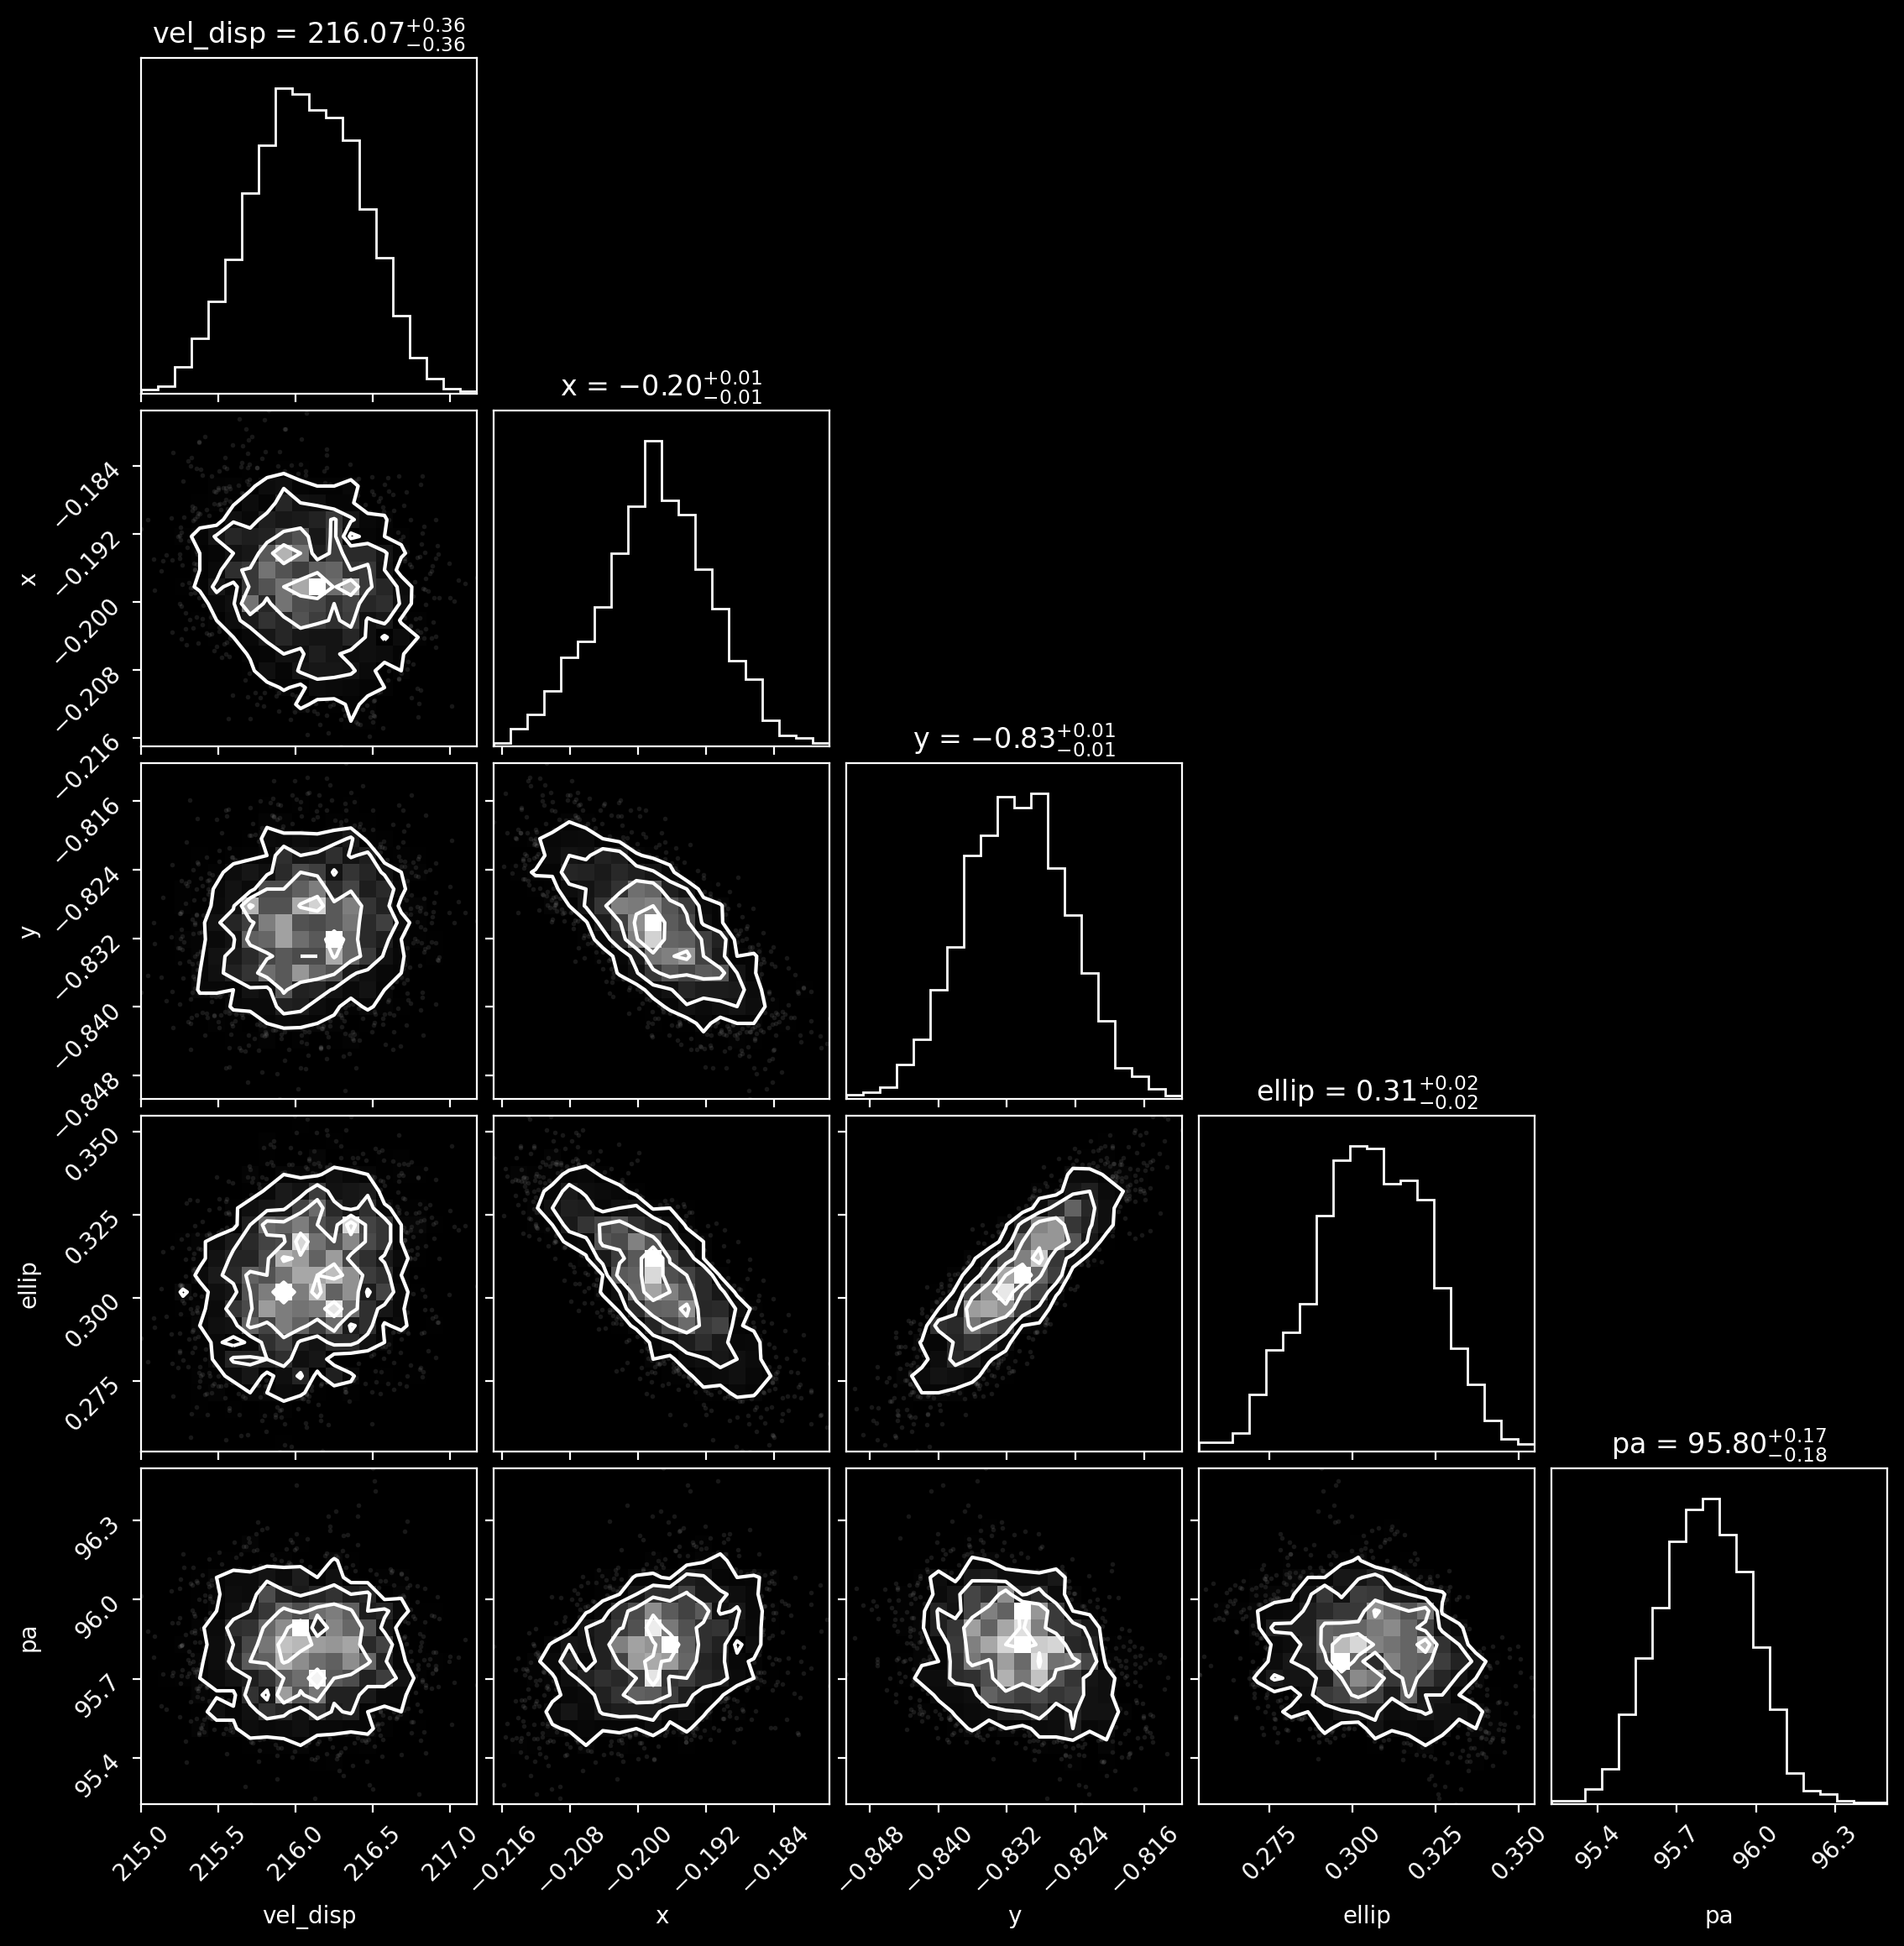

In [70]:
# Remove the first column when loading the samples, as it is the accepted/rejected column
labels = ['vel_disp', 'x', 'y', 'ellip', 'pa']
fig = corner.corner(masked_samples, labels=labels, show_titles=True)
plt.savefig(f'../{system_name}/mcmc/{model_ver}_corner.png')